In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine , load_digits

In [2]:
wine = load_wine(as_frame=True)
X_wine = wine.data
Y_wine = wine.target
print("Features : ",X_wine.columns.to_list())
print("Classes : ",wine.target_names)

Features :  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes :  ['class_0' 'class_1' 'class_2']


In [3]:
X_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [4]:
Y_wine

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

In [7]:
X_wine.describe().loc[["min","max"]]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0


In [8]:
X_wine_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [9]:
def pca_from_scratch(X,n_components):
    cov_mat = np.cov(X.T)
    eigenvalues , eigenvector = np.linalg.eigh(cov_mat)
    sorted_idx = np.argsort(eigenvalues[::-1])
    eigenvalues_sorted = eigenvalues[sorted_idx]
    print(eigenvalues.shape)
    print(eigenvector.shape)
    eigenvector_sorted = eigenvector[:,sorted_idx]
    total_variance = np.sum(eigenvalues_sorted)
    variance_ratio = eigenvalues_sorted/total_variance
    top_k_eigenvectors = eigenvector_sorted[:,:n_components]
    print(top_k_eigenvectors.shape)
    print(X.shape)
    X_projected = X @ top_k_eigenvectors
    print(X_projected.shape)
    return total_variance,top_k_eigenvectors,X_projected,eigenvalues_sorted,variance_ratio

total_variance,top_k_eigenvectors,X_projected,eigenvalues_sorted,variance_ratio =pca_from_scratch(X_wine_scaled,2)
    

(13,)
(13, 13)
(13, 2)
(178, 13)
(178, 2)


In [10]:
from sklearn.decomposition import PCA
sklearn_pca = PCA(n_components=2)
X_pca_sklearn = sklearn_pca.fit_transform(X_wine_scaled)
print("Sklearn explained variance ratio:", sklearn_pca.explained_variance_ratio_.round(4))
print("Scratch explained variance ratio:", variance_ratio[:2].round(4))
print("\n(These should match almost exactly)")
 
print("\nFirst 5 rows - Scratch PCA projection:")
print(X_projected[:5].round(3))
print("\nFirst 5 rows - Sklearn PCA projection:")
print(X_pca_sklearn[:5].round(3))
print("\n(Values may have FLIPPED SIGNS between scratch and sklearn - that's")
print(" fine! An eigenvector v and -v point along the SAME line/axis, just")
print(" in opposite directions. The relative positions of points to each")
print(" other will be identical, just possibly mirrored.)")

Sklearn explained variance ratio: [0.362  0.1921]
Scratch explained variance ratio: [0.362  0.1921]

(These should match almost exactly)

First 5 rows - Scratch PCA projection:
[[-3.317 -1.443]
 [-2.209  0.333]
 [-2.517 -1.031]
 [-3.757 -2.756]
 [-1.009 -0.87 ]]

First 5 rows - Sklearn PCA projection:
[[ 3.317  1.443]
 [ 2.209 -0.333]
 [ 2.517  1.031]
 [ 3.757  2.756]
 [ 1.009  0.87 ]]

(Values may have FLIPPED SIGNS between scratch and sklearn - that's
 fine! An eigenvector v and -v point along the SAME line/axis, just
 in opposite directions. The relative positions of points to each
 other will be identical, just possibly mirrored.)


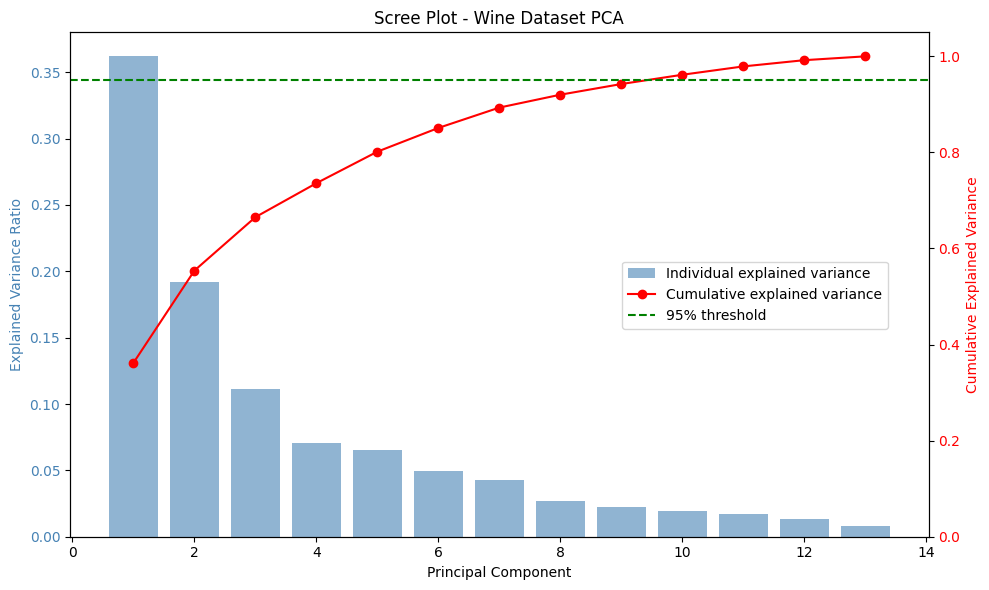


Number of components needed to explain >=95% variance: 10
(Out of 13 original features)

This means we could reduce from 13 dimensions to
10 dimensions while keeping 95% of the information.


In [11]:
cumulative_var = np.cumsum(variance_ratio)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(variance_ratio) + 1), variance_ratio,
        alpha=0.6, color="steelblue", label="Individual explained variance")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var,
         color="red", marker="o", label="Cumulative explained variance")
ax2.axhline(0.95, color="green", linestyle="--", label="95% threshold")
ax2.set_ylabel("Cumulative Explained Variance", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 1.05)
 
plt.title("Scree Plot - Wine Dataset PCA")
fig.legend(loc="center right", bbox_to_anchor=(0.9, 0.5))
plt.tight_layout()
plt.show()

# How many components for 95% variance?
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\nNumber of components needed to explain >=95% variance: {n_components_95}")
print(f"(Out of {X_wine_scaled.shape[1]} original features)")
print(f"\nThis means we could reduce from {X_wine_scaled.shape[1]} dimensions to")
print(f"{n_components_95} dimensions while keeping 95% of the information.")

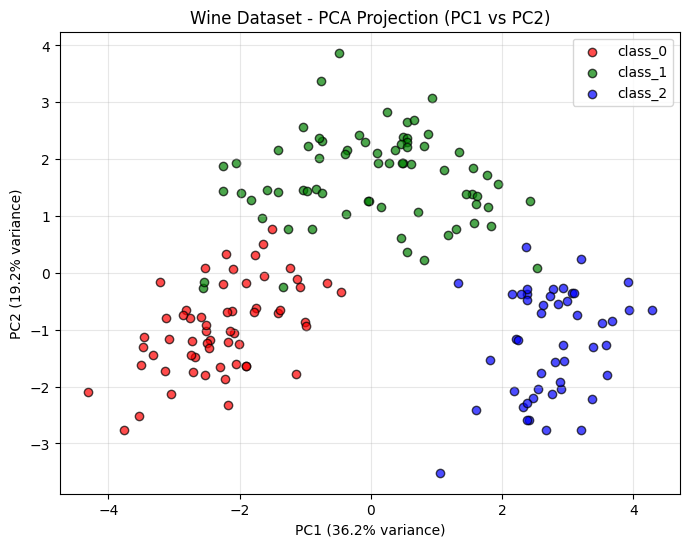

Notice: PCA did NOT use the class labels (y_wine) at all - it only
looked at X. Yet the 3 classes still separate reasonably well. This
is a 'happy accident' - it means the directions of MAXIMUM VARIANCE
happen to ALSO be directions that separate the classes. This is NOT
guaranteed in general - that's exactly the gap LDA is designed to fill.


In [12]:
plt.figure(figsize=(8, 6))
colors = ["red", "green", "blue"]
for class_idx, class_name in enumerate(wine.target_names):
    mask = Y_wine == class_idx
    plt.scatter(X_projected[mask, 0], X_projected[mask, 1],
                c=colors[class_idx], label=class_name, alpha=0.7, edgecolor="k")
 
plt.xlabel(f"PC1 ({variance_ratio[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({variance_ratio[1]*100:.1f}% variance)")
plt.title("Wine Dataset - PCA Projection (PC1 vs PC2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
 
print("Notice: PCA did NOT use the class labels (y_wine) at all - it only")
print("looked at X. Yet the 3 classes still separate reasonably well. This")
print("is a 'happy accident' - it means the directions of MAXIMUM VARIANCE")
print("happen to ALSO be directions that separate the classes. This is NOT")
print("guaranteed in general - that's exactly the gap LDA is designed to fill.")